<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/SHAP_for_Text_Storms.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 6b — What is the model looking at? SHAP for text (NEW for Fall 2026)
- Something new. Video 4's feature_importances_ RANKED words. SHAP adds a DIRECTION - which storm a word pushes toward - and it works one narrative at a time.
- The idea: start from what the model says with every word hidden (the base value), add the words back in every possible order, and a word's SHAP value is its average push. They ADD UP: 0.80 + all the pushes = 0.98 on the first hail narrative.
- Two lines do it: shap.Explainer(forest_predict, shap.maskers.Text(...)). The masker hides words, so the SAME two lines work for a forest and for a neural network.
- Waterfall: 'hail' +0.15, 'size' +0.07, 'inch' +0.06 push toward Hail; 'emergency' -0.07 and 'Rd' -0.06 push the other way - flood-report words.
- The forest's 6 mistakes out of 1,527: 'Heavy rainfall was also observed.' is labelled Hail - no hail words at all, P(Hail) 0.45. SHAP can't find what the text doesn't say.
- Global, 50 narratives: flooding -4.2, water -3.7, road -1.9 push away from Hail; hail +2.7, reported +1.1, size +0.9 push toward it. Same words as feature_importances_ - now with a sign.
- Part 2 is the video-6 network (macro F1 0.67 again). 176 flash floods were called Flood: 'flooded basements... overflowing small lakes' -> P(Flood) 0.91. Flood words: river, stage, crested, melting (slow river floods), and 'flash' pushes AWAY. Flash Flood words: flooded, water, washed, rise - plus 'in', 'of', 'that': the Keras Tokenizer keeps stop words, so even they carry signal.
- SHAP explains the MODEL, not the world. If the model learned a shortcut, SHAP shows you the shortcut - that's why you look (the capstone, video 12, does exactly this).
-->

# What Is the Model Looking At? SHAP for Text

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

In video 4, the random forest's `feature_importances_` told us **which** words it leans on - but not **which storm** each word points to, and not how hard it pushed on one particular narrative. **SHAP** answers both.

We explain the two M5.1 models:
* **Part 1** - the hail vs flash flood random forest (video 4)
* **Part 2** - the 15-storm dense network (video 6)

## The idea, in plain words

Start from what the model says when it can't see ANY of the words - an empty narrative. That's the **base value** (SHAP's plots label it E[f(X)]). Now put the words of ONE narrative back, one at a time, in every possible order, and record how much each word moves the prediction. A word's **SHAP value** is its average push.

The magic property: **SHAP values add up.** Base value + every word's push = exactly the model's prediction for that narrative.

For text, "taking a word out" means **masking** it. SHAP hides words and watches the prediction move - so it works for ANY model that takes text in and gives probabilities out: a forest, a neural network, anything.

In [1]:
# SHAP isn't always pre-installed in Colab - this installs it only if it's missing
import importlib.util
if importlib.util.find_spec('shap') is None:
    !pip install -q shap

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import keras
import tensorflow as tf

# seed everything: same numbers on my screen and yours
# (and we re-seed right before every model build, so model 2 is as reproducible as model 1)
keras.utils.set_random_seed(5509)
tf.config.experimental.enable_op_determinism()
print('shap', shap.__version__)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.48.0


In [3]:
# Link to the data file on Github - the same storm narratives as EDA_ML_Storms and Tokenizer_FFNN_Storms
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module5_Files/data/StormEvents_2019.csv"
storm_df = pd.read_csv(url, header = 0)
print(storm_df.shape)

(61324, 28)


# Part 1 - Hail vs Flash Flood: the forest from video 4

Same two storms as EDA_ML_Storms. To keep this notebook short, `TfidfVectorizer` does the cleaning for us (lowercase + English stop words) instead of the long NLTK recipe - the SHAP ideas are exactly the same.

In [4]:
# the two storm types, narratives only
two = storm_df[(storm_df['EVENT_TYPE'] == 'Hail') | (storm_df['EVENT_TYPE'] == 'Flash Flood')]
two = two.dropna(subset=['EVENT_NARRATIVE'])

# split FIRST
from sklearn.model_selection import train_test_split
X_train_text, X_test_text, y_train, y_test = train_test_split(two['EVENT_NARRATIVE'], two['EVENT_TYPE'],
                                                              test_size=0.2, random_state=5509)
print(X_train_text.shape, X_test_text.shape)

(6107,) (1527,)


In [5]:
# TF-IDF (fit on TRAIN only) + a random forest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

tf_vec = TfidfVectorizer(stop_words='english')
train_tf = tf_vec.fit_transform(X_train_text)
test_tf = tf_vec.transform(X_test_text)

forest = RandomForestClassifier(random_state=5509).fit(train_tf, y_train)
predicted = forest.predict(test_tf)
print('RFC test macro F1:', round(metrics.f1_score(y_test, predicted, average='macro'), 3))
print('classes (column order of predict_proba):', list(forest.classes_))
hail_col = list(forest.classes_).index('Hail')

RFC test macro F1: 0.996
classes (column order of predict_proba): ['Flash Flood', 'Hail']


## Step 1: hand SHAP a function that goes from raw text to probabilities
SHAP doesn't care what's inside - it only needs text in, probabilities out.

In [6]:
def forest_predict(texts):
    """Raw narratives in, [P(Flash Flood), P(Hail)] out - the whole pipeline in one function."""
    return forest.predict_proba(tf_vec.transform(list(texts)))

# the Text masker hides words (it splits the narrative on anything that isn't a letter or a digit)
masker = shap.maskers.Text(r"\W+")
forest_explainer = shap.Explainer(forest_predict, masker, output_names=list(forest.classes_))

## Step 2: explain ONE narrative

In [7]:
one = X_test_text[y_test == 'Hail'].iloc[0]
print(one)
print()

sv_one = forest_explainer([one], silent=True)
print('base value (all words hidden)   :', round(sv_one[0, :, 'Hail'].base_values, 3))
print('base value + sum of SHAP values :', round(sv_one[0, :, 'Hail'].base_values + sv_one[0, :, 'Hail'].values.sum(), 3))
print('the forest says P(Hail) =        ', round(forest_predict([one])[0, hail_col], 3))
# SHAP values ADD UP to the prediction - every time

Retired emergency manager reported dime size to 3/4 inch hail on Vanboklen Rd near Eastover.



base value (all words hidden)   : 0.8
base value + sum of SHAP values : 0.98
the forest says P(Hail) =         0.98


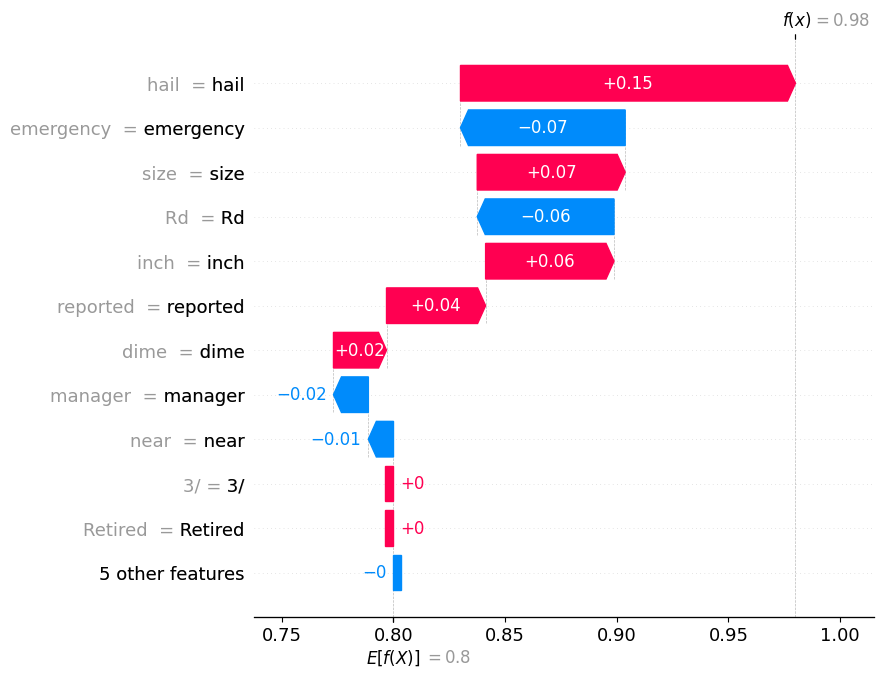

In [8]:
# the waterfall: start at the base value, every word pushes up (red) or down (blue), end at the prediction
shap.plots.waterfall(sv_one[0, :, 'Hail'], max_display=12)

In [9]:
# the same explanation painted on the text: red words push toward Hail, blue words push away
shap.plots.text(sv_one[0, :, 'Hail'])

## Step 3: a hard one - where the forest got it wrong
A 99% model is most interesting on the 1%.

6 mistakes out of 1527 test narratives
actual: Hail | predicted: Flash Flood | P(Hail) = 0.45
Heavy rainfall was also observed.


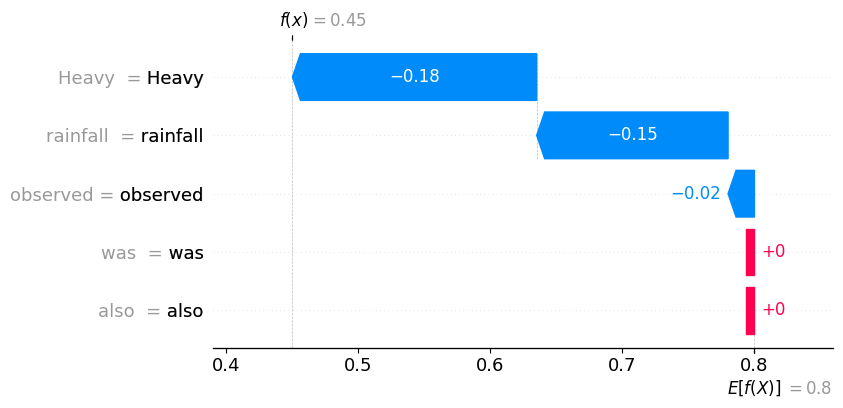

In [10]:
wrong = np.where(predicted != y_test.values)[0]
print(len(wrong), 'mistakes out of', len(y_test), 'test narratives')

if len(wrong) > 0:
    k = wrong[0]
else:
    k = np.argmin(np.abs(forest.predict_proba(test_tf)[:, hail_col] - 0.5))   # no mistakes? take the least sure one

print('actual:', y_test.iloc[k], '| predicted:', predicted[k], '| P(Hail) =', round(forest.predict_proba(test_tf[k])[0, hail_col], 2))
print(X_test_text.iloc[k])

sv_k = forest_explainer([X_test_text.iloc[k]], silent=True)
shap.plots.waterfall(sv_k[0, :, 'Hail'], max_display=12)

## Step 4: the big picture - which words push toward Hail across many narratives?
One narrative at a time is a **local** explanation. Add the pushes up over many narratives and you get a **global** one.

In [11]:
def word_push(explanations, class_name):
    """Total each word's SHAP push toward class_name, across every narrative in the explanation."""
    total_push = {}
    for i in range(len(explanations)):
        words = explanations[i, :, class_name].data
        values = explanations[i, :, class_name].values
        for j in range(len(words)):
            word = re.sub('[^a-z0-9]', '', words[j].lower())    # 'Hail. ' -> 'hail'
            if word == '':
                continue
            total_push[word] = total_push.get(word, 0) + values[j]
    return pd.Series(total_push)


def plot_push(push, class_name, n_words=15):
    """Bar chart of the words with the biggest total push (red = toward class_name, blue = away)."""
    biggest = push.abs().sort_values(ascending=False).index[0:n_words]
    top = push[biggest].sort_values()
    colors = []
    for value in top.values:
        if value > 0:
            colors.append('#d62728')
        else:
            colors.append('#1f77b4')
    top.plot(kind='barh', figsize=(8, 6), color=colors)
    plt.title(f'Total SHAP push toward {class_name}')
    plt.xlabel(f'<- pushes away from {class_name}   |   pushes toward {class_name} ->')
    plt.show()

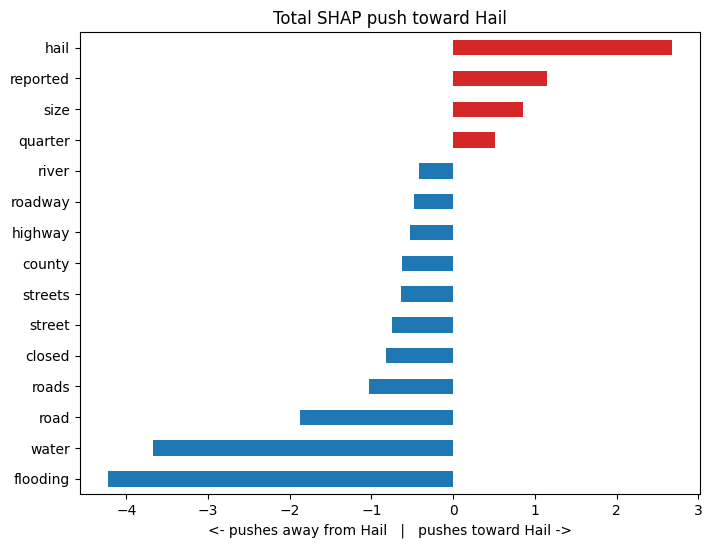

flooding   -4.23
water      -3.68
road       -1.88
roads      -1.02
closed     -0.82
dtype: float64
report      0.23
quarter     0.51
size        0.85
reported    1.14
hail        2.67
dtype: float64


In [12]:
# explain 50 test narratives (about a minute - SHAP re-scores each one many times with words hidden)
sample_texts = list(X_test_text.iloc[0:50])
sv_many = forest_explainer(sample_texts, silent=True)

hail_push = word_push(sv_many, 'Hail')
plot_push(hail_push, 'Hail')
print(hail_push.sort_values()[0:5].round(2))
print(hail_push.sort_values()[-5:].round(2))

Compare this with video 4's `feature_importances_`: the same words sit at the top - but now every word has a **direction**. `feature_importances_` could only say "the forest uses *water* a lot". SHAP says "*water* pushes AWAY from hail, toward flash flood".

# Part 2 - 15 storm types: the dense network from video 6

Same recipe as Tokenizer_FFNN_Storms (same shuffle, same split, same seed), so this is the SAME model you saw in video 6. And SHAP gets used exactly the same way - text in, now 15 probabilities out.

In [13]:
# rebuild the video 6 data - re-seed first so the shuffle matches Tokenizer_FFNN_Storms
keras.utils.set_random_seed(5509)
df = storm_df.sample(frac=1).reset_index(drop=True)
df = df.dropna()
X = df['EVENT_NARRATIVE']

from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y = keras.utils.to_categorical(lb.fit_transform(df['EVENT_TYPE']))
n_outputs = y.shape[1]

X_train_text15, X_test_text15, y_train15, y_test15 = train_test_split(X, y, random_state=42, train_size=0.7)
print(X_train_text15.shape, X_test_text15.shape, n_outputs, 'storm types')

(20276,) (8690,) 15 storm types


In [14]:
# Tokenizer on TRAIN only, TF-IDF of the top 10,000 words
from tensorflow.keras.preprocessing.text import Tokenizer  # Keras 3 dropped keras.preprocessing.text; this path still works in Colab
t = Tokenizer(num_words=10000)
t.fit_on_texts(X_train_text15)
X_train15 = t.texts_to_matrix(X_train_text15, mode='tfidf')
X_test15 = t.texts_to_matrix(X_test_text15, mode='tfidf')
print(X_train15.shape, X_test15.shape)

(20276, 10000) (8690, 10000)


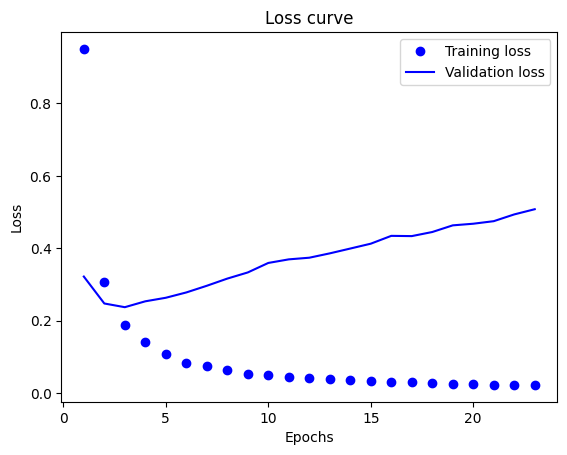

epochs run: 23 | best validation loss: 0.2372 at epoch 3


test macro F1: 0.67 (same model as video 6)


In [15]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping

keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(X_train15.shape[1],)))    # one row of TF-IDF scores in
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(n_outputs, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(X_train15, y_train15,
                    epochs=50,
                    batch_size=100,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=0)

# loss curve - always look at this after a fit!
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Loss curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
print('epochs run:', len(loss), '| best validation loss:', round(min(val_loss), 4), 'at epoch', val_loss.index(min(val_loss)) + 1)

probs15 = model.predict(X_test15, verbose=0)
true15 = y_test15.argmax(axis=1)
pred15 = probs15.argmax(axis=1)
print('test macro F1:', round(metrics.f1_score(true15, pred15, average='macro'), 3), '(same model as video 6)')

In [16]:
def network_predict(texts):
    """Raw narratives in, 15 probabilities out."""
    matrix = t.texts_to_matrix(list(texts), mode='tfidf')
    return model(matrix, training=False).numpy()

network_explainer = shap.Explainer(network_predict, masker, output_names=list(lb.classes_))

## Why did it call this one Flood, not Flash Flood?
Flood vs Flash Flood was the network's biggest confusion in video 6. Let's ask SHAP about one of those mistakes.

176 flash floods were called floods
Several homes experienced flooded basements and flooding from overflowing small lakes at the Amick Acres neighborhood west of Doniphan. With additional bouts of heavy rain, flooding persisted for over a week there. A CoCoRaHS observer near Doniphan measured an incredible 11.91 of rain between Aug. 21-26, and 16.76 for the entire month. Also, shorter-term, 24-hour rain totals from around Hall County on the 22nd (via CoCoRaHS) included 5.98 inches 4 miles south southwest of Alda, 4.54 inches 3 miles west of Doniphan, and 3.67 inches 6 miles west northwest of Hansen.

P(Flood) = 0.91 | P(Flash Flood) = 0.09


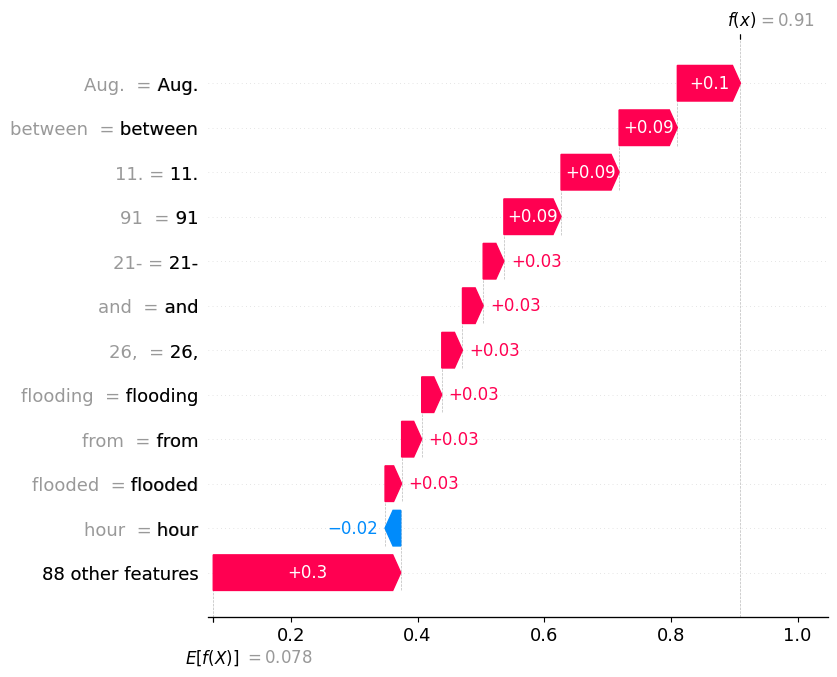

In [17]:
flash = list(lb.classes_).index('Flash Flood')
flood = list(lb.classes_).index('Flood')
mix = np.where((true15 == flash) & (pred15 == flood))[0]
print(len(mix), 'flash floods were called floods')

k = mix[0]
text_k = X_test_text15.iloc[k]
print(text_k)
print()
print('P(Flood) =', round(probs15[k, flood], 2), '| P(Flash Flood) =', round(probs15[k, flash], 2))

sv_mix = network_explainer([text_k], silent=True)
shap.plots.waterfall(sv_mix[0, :, 'Flood'], max_display=12)

In [18]:
# the same narrative, painted for Flash Flood - which words were arguing for the right answer?
shap.plots.text(sv_mix[0, :, 'Flash Flood'])

## Flood vs Flash Flood: the words that tell them apart
Explain 40 test narratives that really were floods or flash floods, then total the pushes for each class.

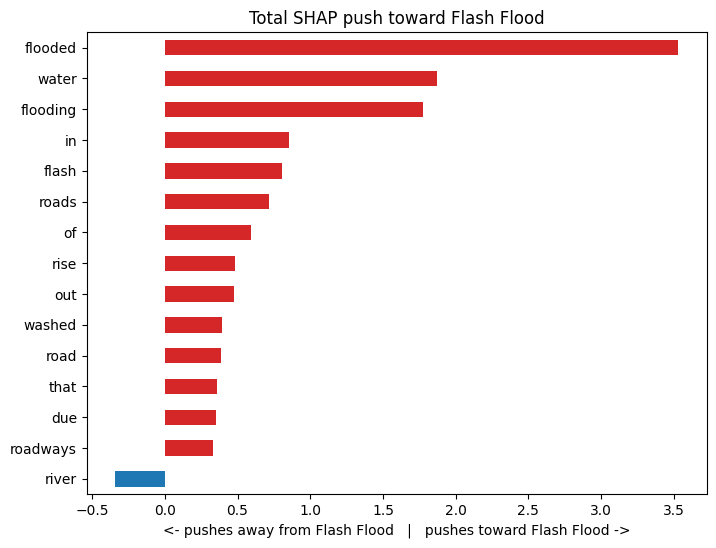

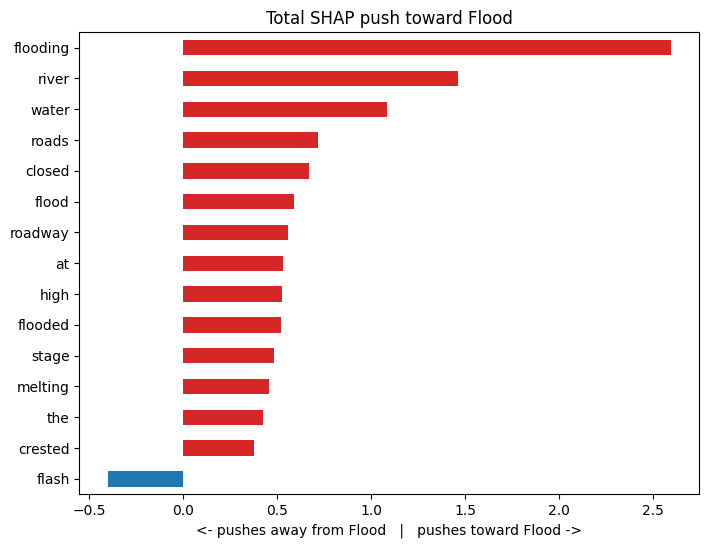

In [19]:
both = np.where((true15 == flash) | (true15 == flood))[0][0:40]
flood_texts = list(X_test_text15.iloc[both])
sv_floods = network_explainer(flood_texts, silent=True)

plot_push(word_push(sv_floods, 'Flash Flood'), 'Flash Flood')
plot_push(word_push(sv_floods, 'Flood'), 'Flood')

# Takeaways
* `feature_importances_` ranks words. **SHAP gives every word a direction and a size** - for one narrative (local) or added up over many (global).
* SHAP values **add up**: base value + every push = the prediction.
* The Text masker works for **any** model - we used the same `shap.Explainer(function, masker)` for a forest and a neural network.
* SHAP explains the **model**, not the world. If the model learned a shortcut, SHAP will faithfully show you the shortcut - which is exactly why you look.

# Terminology
* **Shapley value** - from cooperative game theory (Shapley, 1953): a player's fair share of the payout, averaged over every order the players could join. Here the players are words and the payout is the prediction.
* **SHAP value** - a Shapley value for one feature (word) of one prediction (Lundberg & Lee, 2017, *A Unified Approach to Interpreting Model Predictions*, NeurIPS).
* **Base value** - where every explanation starts: the model's prediction with every word masked (SHAP's plots call it E[f(X)]). For this forest a blank narrative already gets P(Hail) = 0.80.
* **Additivity** - base value + the sum of the SHAP values = the model's prediction.
* **Masker** - how SHAP "removes" a feature. For text, `shap.maskers.Text` hides tokens.
* **Local vs global explanation** - one prediction (waterfall, text plot) vs a pattern across many (the totals).